In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset
df = pd.read_csv("../dataset/TelcoCustomerChurn.csv")
# Menampilkan daftar semua nama kolom di dataset
print(df.columns.tolist())

# Menampilkan informasi dasar
print("--- INFORMASI DATASET ---")
df.info()

print("\n--- PENGECEKAN DATA KOSONG ---")
print(df.isnull().sum())

# Menampilkan nilai apa saja yang ada di dalam kolom ChurnLabel
print("--- DISTRIBUSI CHURN ---")
print(df['ChurnLabel'].value_counts())

print("\n--- ANALISIS FINANSIAL KASAR ---")
# Menghitung jumlah masing-masing kategori menggunakan 'ChurnLabel'
jumlah_churn = df['ChurnLabel'].value_counts()

# Menghitung kerugian dari pelanggan yang ChurnLabel-nya 'Yes' menggunakan 'MonthlyCharge'
kerugian_bulanan = df[df['ChurnLabel'] == 'Yes']['MonthlyCharge'].sum()

print(f"Total Pelanggan: {len(df)} orang")

# get('Yes', 0) digunakan agar tidak error jika format datanya sedikit berbeda
print(f"Pelanggan Keluar (Yes): {jumlah_churn.get('Yes', 0)} orang") 
print(f"Total potensi kerugian bulanan akibat Churn: ${kerugian_bulanan:,.2f}")

['CustomerID', 'Gender', 'Age', 'Under30', 'SeniorCitizen', 'Married', 'Dependents', 'NumberofDependents', 'Country', 'State', 'City', 'ZipCode', 'Latitude', 'Longitude', 'Population', 'Quarter', 'ReferredaFriend', 'Number_of_Referrals', 'TenureinMonths', 'Offer', 'PhoneService', 'AvgMonthlyLongDistanceCharges', 'MultipleLines', 'InternetService', 'InternetType', 'AvgMonthlyGBDownload', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtectionPlan', 'PremiumTechSupport', 'StreamingTV', 'StreamingMovies', 'StreamingMusic', 'UnlimitedData', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharge', 'TotalCharges', 'TotalRefunds', 'TotalExtraDataCharges', 'TotalLongDistanceCharges', 'TotalRevenue', 'SatisfactionScore', 'CustomerStatus', 'ChurnLabel', 'ChurnScore', 'CLTV', 'ChurnCategory', 'ChurnReason']
--- INFORMASI DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  

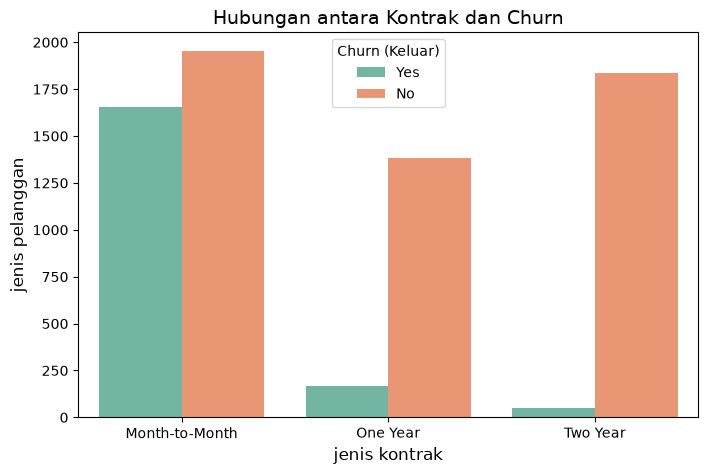

In [5]:
#membuat grafik hubungan antara kontrak dan churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='ChurnLabel', palette='Set2')
plt.title('Hubungan antara Kontrak dan Churn', fontsize=14)
plt.xlabel('jenis kontrak', fontsize=12)
plt.ylabel('jenis pelanggan', fontsize=12)
plt.legend(title='Churn (Keluar)')
plt.show()
 

In [6]:
# Memilih kolom-kolom inti yang paling berdampak pada keputusan pelanggan
kolom_penting = [
    'TenureinMonths',      # Lama berlangganan
    'Contract',            # Jenis kontrak
    'InternetType',        # Jenis internet (Fiber optic, DSL, dll)
    'PremiumTechSupport',  # Layanan bantuan teknis
    'MonthlyCharge',       # Tagihan bulanan
    'TotalCharges',        # Total uang yang sudah dibayar
    'ChurnLabel'           # Target kita
]

# Membuat dataframe baru khusus untuk Machine Learning
df_ml = df[kolom_penting].copy()

# Melihat beberapa baris dari dataset yang sudah dirampingkan
df_ml.head()

,TenureinMonths,Contract,InternetType,PremiumTechSupport,MonthlyCharge,TotalCharges,ChurnLabel
0,1,Month-to-Month,DSL,No,39.65,39.65,Yes
1,8,Month-to-Month,Fiber Optic,No,80.65,633.30,Yes
2,18,Month-to-Month,Fiber Optic,No,95.45,1752.55,Yes
3,25,Month-to-Month,Fiber Optic,No,98.50,2514.50,Yes
4,37,Month-to-Month,Fiber Optic,No,76.50,2868.15,Yes


In [7]:
print("--- PROSES PEMBERSIHAN DATA DIMULAI ---")

# 1. Mengubah target ChurnLabel ('Yes'/'No') menjadi angka (1/0)
# Ini wajib agar AI paham mana yang positif (churn) dan negatif
df_ml['ChurnLabel'] = df_ml['ChurnLabel'].map({'Yes': 1, 'No': 0})

# 2. Menangani kolom 'TotalCharges'
# Kadang data numerik ini terbaca sebagai teks karena ada spasi kosong. Kita paksa jadi angka (numerik).
df_ml['TotalCharges'] = pd.to_numeric(df_ml['TotalCharges'], errors='coerce')

# Jika setelah diubah ada data yang menjadi kosong (NaN), kita hapus saja baris tersebut
jumlah_kosong_sebelum = df_ml['TotalCharges'].isnull().sum()
df_ml.dropna(inplace=True)
print(f"Berhasil menghapus {jumlah_kosong_sebelum} baris data yang cacat/kosong.")

# 3. Mengubah kolom teks lainnya (Kategorikal) menjadi angka menggunakan metode 'One-Hot Encoding'
# Ini akan memecah kolom seperti 'Contract' menjadi 'Contract_One Year', 'Contract_Two Year' bernilai 0 dan 1
df_ml_final = pd.get_dummies(df_ml, drop_first=True)

# Memastikan semua data sekarang sudah berupa angka
print("\n--- INFO DATA SIAP TRAINING ---")
df_ml_final.info()

--- PROSES PEMBERSIHAN DATA DIMULAI ---
Berhasil menghapus 0 baris data yang cacat/kosong.

--- INFO DATA SIAP TRAINING ---
<class 'pandas.DataFrame'>
Index: 5517 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TenureinMonths            5517 non-null   int64  
 1   MonthlyCharge             5517 non-null   float64
 2   TotalCharges              5517 non-null   float64
 3   ChurnLabel                5517 non-null   int64  
 4   Contract_One Year         5517 non-null   bool   
 5   Contract_Two Year         5517 non-null   bool   
 6   InternetType_DSL          5517 non-null   bool   
 7   InternetType_Fiber Optic  5517 non-null   bool   
 8   PremiumTechSupport_Yes    5517 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 242.4 KB


In [8]:
from sklearn.model_selection import train_test_split

print("--- PROSES PEMBAGIAN DATA ---")

# Memisahkan Fitur (X) pendukung dan Target (y) yang ingin ditebak
# Target kita adalah kolom 'ChurnLabel'
X = df_ml_final.drop('ChurnLabel', axis=1)
y = df_ml_final['ChurnLabel']

# Membagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data untuk AI belajar: {X_train.shape[0]} pelanggan")
print(f"Jumlah data untuk AI ujian: {X_test.shape[0]} pelanggan")

--- PROSES PEMBAGIAN DATA ---
Jumlah data untuk AI belajar: 4413 pelanggan
Jumlah data untuk AI ujian: 1104 pelanggan


In [10]:
from sklearn.ensemble import RandomForestClassifier

print("--- MELATIH MODEL MACHINE LEARNING ---")

# Membuat 'otak' AI menggunakan Random Forest
# random_state=42 digunakan agar hasil Anda dan saya tetap sama jika diulang
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Menyuruh AI belajar (Proses Training)
model_rf.fit(X_train, y_train)

print("Proses belajar selesai!.")

--- MELATIH MODEL MACHINE LEARNING ---
Proses belajar selesai!.


--- HASIL UJIAN AI (EVALUASI MODEL) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       753
           1       0.56      0.64      0.60       351

    accuracy                           0.72      1104
   macro avg       0.69      0.70      0.69      1104
weighted avg       0.74      0.72      0.73      1104



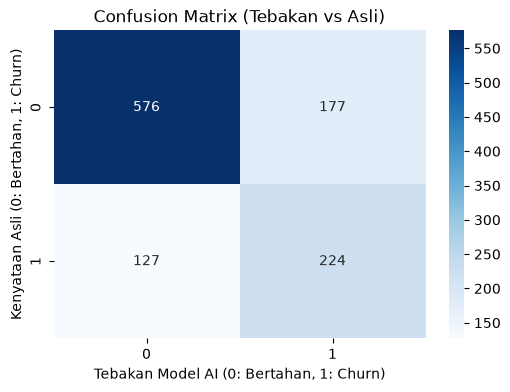

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- HASIL UJIAN AI (EVALUASI MODEL) ---")

# Meminta AI menebak data ujian
y_pred = model_rf.predict(X_test)

# Menampilkan Rapor Evaluasi
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix dengan visualisasi
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tebakan vs Asli)')
plt.ylabel('Kenyataan Asli (0: Bertahan, 1: Churn)')
plt.xlabel('Tebakan Model AI (0: Bertahan, 1: Churn)')
plt.show()

In [12]:
import pickle

# Kita membungkus model dan data testing ke dalam satu paket
data_to_save = {
    'model': model_rf,
    'X_test': X_test,
    'y_test': y_test
}

# Menyimpan paket tersebut ke dalam file berekstensi .pkl
with open('churn_model_data.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

print("Sukses! Model AI dan data berhasil disimpan ke dalam 'churn_model_data.pkl'.")

Sukses! Model AI dan data berhasil disimpan ke dalam 'churn_model_data.pkl'.
